In [1]:
!pip -q install brian2 cirq qsimcirq transformers accelerate datasets sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch timm opencv-python decord

# System dependency: ffmpeg
import shutil, os, sys, subprocess
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found. Install it on your OS:")
    print("  Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("  macOS:  brew install ffmpeg")
    print("  Win:    choco install ffmpeg")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 7.7 MB/s eta 0:00:00


In [2]:
import zipfile, os, json, glob

zip_path = "/content/data/synthdata.zip"  # Corrected path
out_dir = "./data"

os.makedirs(out_dir, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

root = os.path.join(out_dir, "synthdata", "synth")
print("Root:", root)
print("Files:", sorted(os.listdir(root))[:20])

manifest = os.path.join(root, "manifest.jsonl")
print("Manifest exists:", os.path.exists(manifest))
print("Example line:", open(manifest, "r", encoding="utf-8").readline()[:200])

Root: ./data/synthdata/synth
Files: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'images', 'manifest.jsonl', 'text', 'video']
Manifest exists: True
Example line: {"i": 0, "timestamp": "2025-08-17T09:56:43.222236", "script_name": "model", "script_id": 4, "cycle": 1, "text": "[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=


In [3]:
import shutil
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

# System dependency: ffmpeg
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")

In [4]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [5]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "/content/data/synthdata.zip"  # Corrected path
OUT_DIR  = "./data"

os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [6]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))

./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [8]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
txt_name = "sentence-transformers/all-MiniLM-L6-v2"

txt_tok = AutoTokenizer.from_pretrained(txt_name)
txt_model = AutoModel.from_pretrained(txt_name).to(torch_device).eval()

@torch.no_grad()
def embed_text(texts):
    batch = txt_tok(texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


In [9]:
import open_clip
from PIL import Image
import torchvision.transforms as T

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="laion2b_s34b_b79k")
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_image(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [10]:
import whisper
import numpy as np

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))  # (1, frames, dim)
        emb = enc.mean(dim=1)                     # (1, dim)
        embs.append(emb.squeeze(0))
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


100%|███████████████████████████████████████| 139M/139M [00:12<00:00, 11.2MiB/s]


In [11]:
import decord
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1,0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        # preprocess like CLIP
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0, keepdim=True)       # (1,D)
        all_embs.append(zv.squeeze(0))
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)


In [12]:
import numpy as np
from brian2 import *

def brian2_rate_features(x_np, sim_ms=50.0):
    """
    x_np: (B, D) numpy float32 in [-1,1] or [0,1]
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    # normalize to [0,1] current
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms

    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        # spikes per neuron / second
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        # reset Brian2 state between samples
        brian2_device.reinit()
        brian2_device.activate()
    return np.stack(rates_out, axis=0)

In [13]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)

In [14]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)

In [15]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)

In [16]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx).permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)

In [17]:
from transformers import pipeline
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
print("Sentiment scores (first 5):", s_scores[:5])
print("Average sentiment score:", s_scores.mean())

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


Sentiment scores (first 5): [0.00513488 0.00370187 0.00497109 0.00513488 0.00445032]
Average sentiment score: 0.25469384


In [18]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)

Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [19]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x

In [20]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

In [21]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)

In [22]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)

torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [23]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [24]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 40001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9329
epoch   50  loss 28.5802
epoch  100  loss 21.7362
epoch  150  loss 18.5208
epoch  200  loss 14.0325
epoch  250  loss 12.7685
epoch  300  loss 12.0097
epoch  350  loss 11.8944
epoch  400  loss 12.3831
epoch  450  loss 11.9358
epoch  500  loss 11.8644
epoch  550  loss 11.7639
epoch  600  loss 11.7586
epoch  650  loss 11.6934
epoch  700  loss 11.6924
epoch  750  loss 11.6710
epoch  800  loss 11.6876
epoch  850  loss 11.7191
epoch  900  loss 11.6845
epoch  950  loss 11.6330
epoch 1000  loss 11.6540
epoch 1050  loss 11.6403
epoch 1100  loss 11.6268
epoch 1150  loss 11.7046
epoch 1200  loss 11.6485
epoch 1250  loss 18.8949
epoch 1300  loss 12.1832
epoch 1350  loss 11.7210
epoch 1400  loss 11.6793
epoch 1450  loss 11.6690
epoch 1500  loss 11.6397
epoch 1550  loss 11.6246
epoch 1600  loss 11.6405
epoch 1650  loss 11.6244
epoch 1700  loss 11.6553
epoch 1750  loss 11.6210
epoch 1800  loss 11.6197
epoch 1850  loss 11.6011
epoch 1900  loss 11.6158
epoch 1950  loss 11.6073


In [25]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(2, 0.8343725204467773, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (14, 0.8343725204467773, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (15, 0.8343725204467773, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (13, 0.8343725204467773, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (16, 0.41635096073150635, './data/synthdata/synth/video/client_c000002_0000016.mp4')]


Generating parallax view for the first image...


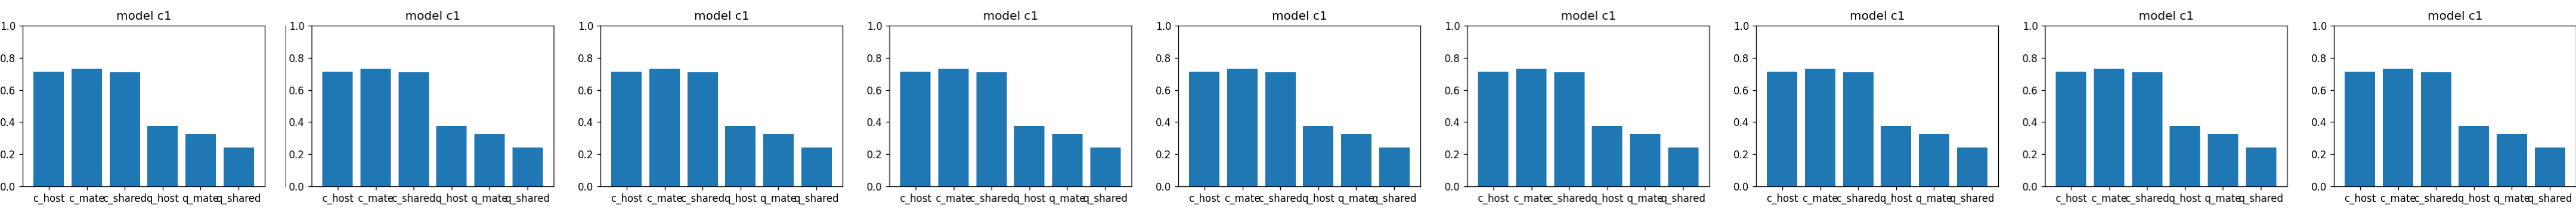

In [26]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [27]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)

E_t_aug: torch.Size([49, 528])


In [28]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 40001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

epoch    1  loss 38.9369
epoch   50  loss 28.7850
epoch  100  loss 25.5862
epoch  150  loss 20.9669
epoch  200  loss 17.3820
epoch  250  loss 14.2476
epoch  300  loss 13.2547
epoch  350  loss 12.1747
epoch  400  loss 12.1997
epoch  450  loss 11.8442
epoch  500  loss 11.7660
epoch  550  loss 11.7103
epoch  600  loss 11.7372
epoch  650  loss 11.7198
epoch  700  loss 11.7569
epoch  750  loss 11.6833
epoch  800  loss 11.6601
epoch  850  loss 11.6379
epoch  900  loss 11.6564
epoch  950  loss 11.6469
epoch 1000  loss 11.6512
epoch 1050  loss 11.6205
epoch 1100  loss 11.6405
epoch 1150  loss 11.6210
epoch 1200  loss 11.6398
epoch 1250  loss 11.6702
epoch 1300  loss 11.6176
epoch 1350  loss 11.6231
epoch 1400  loss 11.6452
epoch 1450  loss 11.6622
epoch 1500  loss 11.5969
epoch 1550  loss 11.6077
epoch 1600  loss 11.6235
epoch 1650  loss 11.6043
epoch 1700  loss 11.6781
epoch 1750  loss 11.6550
epoch 1800  loss 11.6067
epoch 1850  loss 11.6178
epoch 1900  loss 11.6590
epoch 1950  loss 11.6035


In [29]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

# Example usage:
print(retrieve_text_to_video("drifting mood model cycle", topk=5))

[(2, 0.8030790090560913, './data/synthdata/synth/video/client_c000001_0000002.mp4'), (13, 0.8030790090560913, './data/synthdata/synth/video/client_c000001_0000013.mp4'), (14, 0.8030790090560913, './data/synthdata/synth/video/client_c000002_0000014.mp4'), (15, 0.8030790090560913, './data/synthdata/synth/video/client_c000002_0000015.mp4'), (45, 0.40578722953796387, './data/synthdata/synth/video/brian_c000001_0000045.mp4')]


Generating parallax view for the first image...


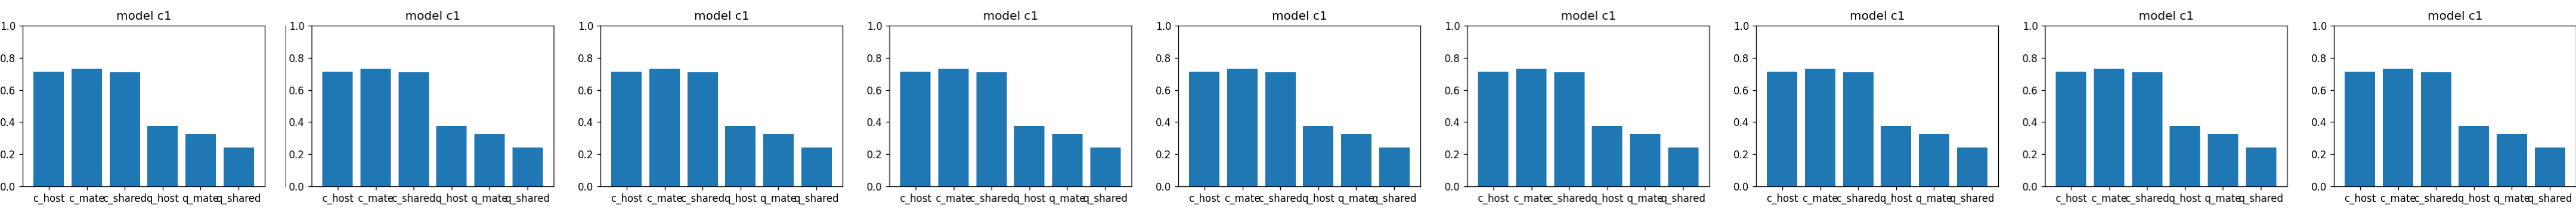

In [30]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
print("Generating parallax view for the first image...")
parallax_views(img_paths[0], n_views=9, max_shift=18)

In [31]:
import cirq
import qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    """
    x_np: (B, D) -> use first n_qubits features as angles
    returns: (B, 2*n_qubits) expectation features
    """
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)

    simulator = qsimcirq.QSimSimulator()

    feats = []
    for b in range(B):
        angles = x_np[b, :n_qubits]
        circuit = cirq.Circuit()
        # simple encoding
        for i, q in enumerate(qubits):
            circuit.append(cirq.ry(float(angles[i]))(q))
            circuit.append(cirq.rz(float(angles[i]))(q))

        # entangle
        for _ in range(reps):
            for i in range(n_qubits-1):
                circuit.append(cirq.CNOT(qubits[i], qubits[i+1]))

        # measure expectations via statevector
        result = simulator.simulate(circuit)
        state = result.final_state_vector

        # crude “features”: probabilities of |0> on each qubit (from statevector marginals)
        # For small n_qubits this is OK.
        probs = np.abs(state)**2
        # marginal P(q=0)
        q0 = []
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [32]:
import json, os

def load_manifest(root):
    items = []
    with open(os.path.join(root, "manifest.jsonl"), "r", encoding="utf-8") as f:
        for line in f:
            j = json.loads(line)
            # Fix paths if they start with /content/...
            def fix(p):
                if p is None: return None
                p = p.replace("/content/synth/", "")
                return os.path.join(root, p) if not os.path.isabs(p) else p
            items.append({
                "text": j.get("text",""),
                "img": fix(j.get("img_path")),
                "aud": fix(j.get("aud_path")),
                "vid": fix(j.get("vid_path")),
            })
    return items

items = load_manifest(root)
items[0]


{'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).',
 'img': None,
 'aud': None,
 'vid': None}

In [33]:
import torch.nn as nn
import torch.nn.functional as F
import random

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

# Filter items to only include entries where all modalities are present
# This is necessary because the original manifest contains entries with missing image, audio, or video paths
filtered_items = [
    item for item in items
    if item["img"] is not None and item["aud"] is not None and item["vid"] is not None and item["text"] is not None
]

if not filtered_items:
    print("Warning: No items found with all modalities (text, image, audio, video). Skipping embedding and training.")
else:
    # Extract modalities from filtered items
    texts = [it["text"] for it in filtered_items]
    imgs  = [it["img"]  for it in filtered_items]
    auds  = [it["aud"]  for it in filtered_items]
    vids  = [it["vid"]  for it in filtered_items]

    E_t = embed_text(texts)
    E_i = embed_image(imgs)
    E_a = embed_audio(auds)
    E_v = embed_video(vids)

    proj_t = Projector(E_t.shape[1]).to(torch_device)
    proj_i = Projector(E_i.shape[1]).to(torch_device)
    proj_a = Projector(E_a.shape[1]).to(torch_device)
    proj_v = Projector(E_v.shape[1]).to(torch_device)

    opt = torch.optim.AdamW(
        list(proj_t.parameters())+list(proj_i.parameters())+list(proj_a.parameters())+list(proj_v.parameters()),
        lr=2e-3, weight_decay=1e-4
    )

    N = E_t.size(0)

    for epoch in range(1, 30001):
        idx = torch.randperm(N, device=torch_device)
        # full-batch is fine for N=49
        zt = proj_t(E_t[idx])
        zi = proj_i(E_i[idx])
        za = proj_a(E_a[idx])
        zv = proj_v(E_v[idx])

        loss = (info_nce(zt, zi)+info_nce(zt, za)+info_nce(zt, zv)+
                info_nce(zi, za)+info_nce(zi, zv)+
                info_nce(za, zv))

        opt.zero_grad()
        loss.backward()
        opt.step()

        if epoch % 50 == 0 or epoch == 1:
            print(f"epoch {epoch:4d}  loss {loss.item():.4f}")

In [34]:
!pip -q install brian2 cirq qsimcirq transformers accelerate sentencepiece \
    openai-whisper ffmpeg-python torchaudio soundfile \
    open-clip-torch opencv-python decord pillow

import shutil
if shutil.which("ffmpeg") is None:
    print("ffmpeg not found on OS. Install it:")
    print("Ubuntu: sudo apt-get update && sudo apt-get install -y ffmpeg")
    print("macOS:  brew install ffmpeg")
    print("Win:    choco install ffmpeg")


In [35]:
import os, zipfile, json, numpy as np, pathlib, shutil

ZIP_PATH = "/content/data/synthdata.zip"  # Corrected path
OUT_DIR  = "./data"

# The following lines caused the FileNotFoundError by deleting the zip file before it could be read.
# if os.path.exists(OUT_DIR):
#     shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

print("ROOT:", ROOT)
print("ROOT contents:", sorted(os.listdir(ROOT)))
print("Manifest:", manifest_path, "exists:", os.path.exists(manifest_path))

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        j=json.loads(line)
        items.append(j)

print("N items:", len(items))
print("Example:", items[0])

ROOT: ./data/synthdata/synth
ROOT contents: ['E_aud.npy', 'E_img.npy', 'E_text.npy', 'E_vid.npy', 'audio', 'haptics', 'images', 'manifest.jsonl', 'text', 'video']
Manifest: ./data/synthdata/synth/manifest.jsonl exists: True
N items: 49
Example: {'i': 0, 'timestamp': '2025-08-17T09:56:43.222236', 'script_name': 'model', 'script_id': 4, 'cycle': 1, 'text': '[model] cycle=1 mood=drifting. classical(H=0.714, M=0.733, S=0.709) quantum(H=0.376, M=0.328, S=0.240).', 'image_path': '/content/synth/images/model_c000001_0000000.png', 'audio_path': '/content/synth/audio/model_c000001_0000000.wav', 'video_path': '/content/synth/video/model_c000001_0000000.mp4'}


In [36]:
def fix_path(p: str) -> str:
    # manifest has /content/synth/images/...
    # your extracted tree is ROOT/images/...
    if p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def get_paths(items):
    texts, imgs, auds, vids = [], [], [], []
    for j in items:
        texts.append(j["text"])
        imgs.append(fix_path(j["image_path"]))
        auds.append(fix_path(j["audio_path"]))
        vids.append(fix_path(j["video_path"]))
    return texts, imgs, auds, vids

texts, img_paths, aud_paths, vid_paths = get_paths(items)

print(img_paths[0], os.path.exists(img_paths[0]))
print(aud_paths[0], os.path.exists(aud_paths[0]))
print(vid_paths[0], os.path.exists(vid_paths[0]))


./data/synthdata/synth/images/model_c000001_0000000.png True
./data/synthdata/synth/audio/model_c000001_0000000.wav True
./data/synthdata/synth/video/model_c000001_0000000.mp4 True


In [37]:
import torch
from transformers import AutoTokenizer, AutoModel

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(batch_texts):
    batch = txt_tok(batch_texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state  # (B,T,H)
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return torch.nn.functional.normalize(pooled, dim=-1)


In [38]:
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return torch.nn.functional.normalize(z, dim=-1)


In [39]:
import whisper

wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(torch_device)
        enc = wh_model.encoder(mel.unsqueeze(0))   # (1, frames, dim)
        emb = enc.mean(dim=1).squeeze(0)          # (dim,)
        embs.append(emb)
    embs = torch.stack(embs)
    return torch.nn.functional.normalize(embs, dim=-1)


In [99]:
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1, 0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx)
        # Explicitly convert to torch.Tensor if decord.bridge.set_bridge("torch") isn't working
        if not isinstance(frames, torch.Tensor):
            frames = torch.from_numpy(frames.asnumpy())

        frames = frames.to(torch_device)
        frames = frames.permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)  # (F,D)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return torch.nn.functional.normalize(all_embs, dim=-1)

In [41]:
from transformers import pipeline

sent_pipe = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english", device=0 if device=="cuda" else -1)

def sentiment_scores(texts):
    # returns float in [0,1] where 1=positive
    outs = sent_pipe(texts, truncation=True)
    scores = []
    for o in outs:
        if o["label"].upper().startswith("POS"):
            scores.append(float(o["score"]))
        else:
            scores.append(1.0 - float(o["score"]))
    return np.array(scores, dtype=np.float32)

s_scores = sentiment_scores(texts)
s_scores[:5], s_scores.mean()


Device set to use cpu


(array([0.00513488, 0.00370187, 0.00497109, 0.00513488, 0.00445032],
       dtype=float32),
 np.float32(0.25469384))

In [42]:
import torch
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [43]:
!apt-get update -qq && apt-get install -qq -y ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [44]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 4.4 MB/s eta 0:00:00
Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [45]:
import torch.nn as nn
import torch.nn.functional as F

class HapticsEncoder(nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.proj = nn.Linear(64, out_dim)

    def forward(self, x):  # x: (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

def load_haptics_batch(paths):
    arr = [np.load(p) for p in paths]  # each (T,3)
    x = torch.tensor(np.stack(arr, axis=0), dtype=torch.float32, device=torch_device)
    return x


In [46]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [47]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [48]:
import torch
!pip install torchcodec
import soundfile as sf
import numpy as np

HAPT_DIR = os.path.join(ROOT, "haptics")
os.makedirs(HAPT_DIR, exist_ok=True)

def gen_haptics_for_audio(wav_path, sentiment, T=200):
    audio, sr = sf.read(wav_path, dtype="float32", always_2d=True)
    wav = torch.tensor(audio).T  # (ch,n)  # (ch, n)
    wav = wav.mean(dim=0)                # mono
    # energy envelope
    hop = max(1, wav.shape[0] // T)
    env = []
    for i in range(T):
        seg = wav[i*hop:(i+1)*hop]
        env.append(seg.abs().mean().item() if seg.numel() else 0.0)
    env = np.array(env, dtype=np.float32)
    env = (env - env.min()) / (env.max() - env.min() + 1e-8)

    # sentiment modulates "smoothness" and intensity
    vib = np.clip(0.2 + 0.8*(0.6*env + 0.4*sentiment), 0, 1)

    # pulse proxy: more pulses if negative/tense (1-sentiment)
    pulse = np.clip((1.0 - sentiment) * (0.3 + 0.7*env), 0, 1)

    # pressure proxy: stable “force” tied to env but biased by sentiment
    force = np.clip(0.1 + 0.9*(0.7*env + 0.3*sentiment), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

hapt_paths = []
for j, wav_path, s in zip(items, aud_paths, s_scores):
    hp = os.path.join(HAPT_DIR, f"{j['i']:04d}.npy")
    np.save(hp, gen_haptics_for_audio(wav_path, float(s), T=200))
    hapt_paths.append(hp)

print("Saved haptics:", hapt_paths[0], np.load(hapt_paths[0]).shape)


Saved haptics: ./data/synthdata/synth/haptics/0000.npy (200, 3)


In [49]:
!ffmpeg -version

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-l

In [50]:
from brian2 import *
import numpy as np

def brian2_rate_features(x_np, sim_ms=30.0):
    """
    x_np: (B, D) float32
    returns: (B, D) spike rates
    """
    B, D = x_np.shape
    x = x_np
    x = (x - x.min()) / (x.max() - x.min() + 1e-8)

    defaultclock.dt = 0.1*ms
    tau = 10*ms
    eqs = '''
    dv/dt = (-v + I)/tau : 1
    I : 1
    '''

    rates_out = []
    for b in range(B):
        G = NeuronGroup(D, eqs, threshold='v>1', reset='v=0', method='euler')
        G.I = x[b]
        M = SpikeMonitor(G)
        run(sim_ms*ms)
        rate = np.array(M.count) / (sim_ms/1000.0)
        rates_out.append(rate.astype(np.float32))
        device.reinit(); device.activate()
    return np.stack(rates_out, axis=0)

# Example: make spiking features from text embeddings (first 128 dims for speed)


In [51]:
import cirq, qsimcirq
import numpy as np

def quantum_features(x_np, n_qubits=8, reps=2):
    B, D = x_np.shape
    qubits = cirq.LineQubit.range(n_qubits)
    sim = qsimcirq.QSimSimulator()

    feats=[]
    for b in range(B):
        angles = x_np[b, :n_qubits]
        c = cirq.Circuit()
        for i,q in enumerate(qubits):
            c.append(cirq.ry(float(angles[i]))(q))
            c.append(cirq.rz(float(angles[i]))(q))
        for _ in range(reps):
            for i in range(n_qubits-1):
                c.append(cirq.CNOT(qubits[i], qubits[i+1]))
        r = sim.simulate(c)
        state = r.final_state_vector
        probs = np.abs(state)**2

        q0=[]
        for qi in range(n_qubits):
            mask = 1 << (n_qubits-1-qi)
            p0 = probs[[i for i in range(len(probs)) if (i & mask)==0]].sum()
            q0.append(p0)
        q0 = np.array(q0, dtype=np.float32)
        feats.append(np.concatenate([q0, 1.0-q0], axis=0))
    return np.stack(feats, axis=0)


In [52]:
import torch

E_t = embed_text(texts)
E_i = embed_images(img_paths)
E_a = embed_audio(aud_paths)
E_v = embed_video(vid_paths)

print(E_t.shape, E_i.shape, E_a.shape, E_v.shape)


torch.Size([49, 384]) torch.Size([49, 512]) torch.Size([49, 512]) torch.Size([49, 512])


In [53]:
import numpy as np

# --- Text synaptic+quantum augmentation (fast enough for N=49) ---
E_t_np = E_t.detach().cpu().numpy().astype(np.float32)

S_t = brian2_rate_features(E_t_np[:, :128], sim_ms=25.0)      # synaptic features
Q_t = quantum_features(E_t_np[:, :8], n_qubits=8, reps=2)     # quantum features

E_t_aug = torch.tensor(np.concatenate([E_t_np, S_t, Q_t], axis=1), device=torch_device, dtype=torch.float32)
E_t_aug = torch.nn.functional.normalize(E_t_aug, dim=-1)

print("E_t_aug:", E_t_aug.shape)


E_t_aug: torch.Size([49, 528])


In [54]:
import torch.nn as nn
import torch.nn.functional as F

class Projector(nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

def info_nce(a, b, temp=0.07):
    logits = (a @ b.T) / temp
    labels = torch.arange(a.size(0), device=a.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

h_enc = HapticsEncoder(in_ch=3, out_dim=256).to(torch_device)

p_t = Projector(E_t_aug.shape[1]).to(torch_device)
p_i = Projector(E_i.shape[1]).to(torch_device)
p_a = Projector(E_a.shape[1]).to(torch_device)
p_v = Projector(E_v.shape[1]).to(torch_device)

opt = torch.optim.AdamW(
    list(h_enc.parameters()) + list(p_t.parameters()) + list(p_i.parameters()) +
    list(p_a.parameters()) + list(p_v.parameters()),
    lr=2e-3, weight_decay=1e-4
)

H = load_haptics_batch(hapt_paths)      # (N,T,3)
N = E_i.shape[0]

for epoch in range(1, 40001):
    idx = torch.randperm(N, device=torch_device)

    zt = p_t(E_t_aug[idx])
    zi = p_i(E_i[idx])
    za = p_a(E_a[idx])
    zv = p_v(E_v[idx])
    zh = h_enc(H[idx])

    # all-pairs contrastive (5 modalities)
    loss = (
        info_nce(zt, zi) + info_nce(zt, za) + info_nce(zt, zv) + info_nce(zt, zh) +
        info_nce(zi, za) + info_nce(zi, zv) + info_nce(zi, zh) +
        info_nce(za, zv) + info_nce(za, zh) +
        info_nce(zv, zh)
    )

    opt.zero_grad()
    loss.backward()
    opt.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d}  loss {loss.item():.4f}")


epoch    1  loss 38.9330
epoch   50  loss 28.7467
epoch  100  loss 24.7802
epoch  150  loss 19.9210
epoch  200  loss 15.2252
epoch  250  loss 14.4368
epoch  300  loss 12.4199
epoch  350  loss 12.1755
epoch  400  loss 11.8654
epoch  450  loss 11.8361
epoch  500  loss 11.7914
epoch  550  loss 16.6688
epoch  600  loss 11.9482
epoch  650  loss 11.7921
epoch  700  loss 11.6998
epoch  750  loss 11.6864
epoch  800  loss 11.6555
epoch  850  loss 11.6908
epoch  900  loss 11.6674
epoch  950  loss 11.6646
epoch 1000  loss 11.6309
epoch 1050  loss 11.6719
epoch 1100  loss 11.6266
epoch 1150  loss 11.6292
epoch 1200  loss 11.6408
epoch 1250  loss 11.6894
epoch 1300  loss 11.6397
epoch 1350  loss 11.6367
epoch 1400  loss 11.6121
epoch 1450  loss 19.4913
epoch 1500  loss 13.6325
epoch 1550  loss 11.9162
epoch 1600  loss 11.7733
epoch 1650  loss 11.7046
epoch 1700  loss 11.6740
epoch 1750  loss 11.6774
epoch 1800  loss 11.6413
epoch 1850  loss 11.6733
epoch 1900  loss 11.6359
epoch 1950  loss 11.6280


In [55]:
@torch.no_grad()
def retrieve_text_to_video(query_text, topk=5):
    q = embed_text([query_text])
    # augment query in same way:
    q_np = q.detach().cpu().numpy().astype(np.float32)
    S_q = brian2_rate_features(q_np[:, :128], sim_ms=25.0)
    Q_q = quantum_features(q_np[:, :8], n_qubits=8, reps=2)
    q_aug = torch.tensor(np.concatenate([q_np, S_q, Q_q], axis=1), device=torch_device, dtype=torch.float32)
    q_aug = torch.nn.functional.normalize(q_aug, dim=-1)

    zq = p_t(q_aug)                # (1,256)
    zv_all = p_v(E_v)              # (N,256)
    sims = (zq @ zv_all.T).squeeze(0)
    vals, inds = torch.topk(sims, k=min(topk, len(sims)))
    return [(int(i.item()), float(v.item()), vid_paths[int(i.item())]) for v,i in zip(vals, inds)]

retrieve_text_to_video("drifting mood model cycle", topk=5)


[(15,
  0.6548367738723755,
  './data/synthdata/synth/video/client_c000002_0000015.mp4'),
 (13,
  0.6548367738723755,
  './data/synthdata/synth/video/client_c000001_0000013.mp4'),
 (14,
  0.6548367738723755,
  './data/synthdata/synth/video/client_c000002_0000014.mp4'),
 (2,
  0.6548367738723755,
  './data/synthdata/synth/video/client_c000001_0000002.mp4'),
 (11,
  0.4565342962741852,
  './data/synthdata/synth/video/cookie_c000002_0000011.mp4')]

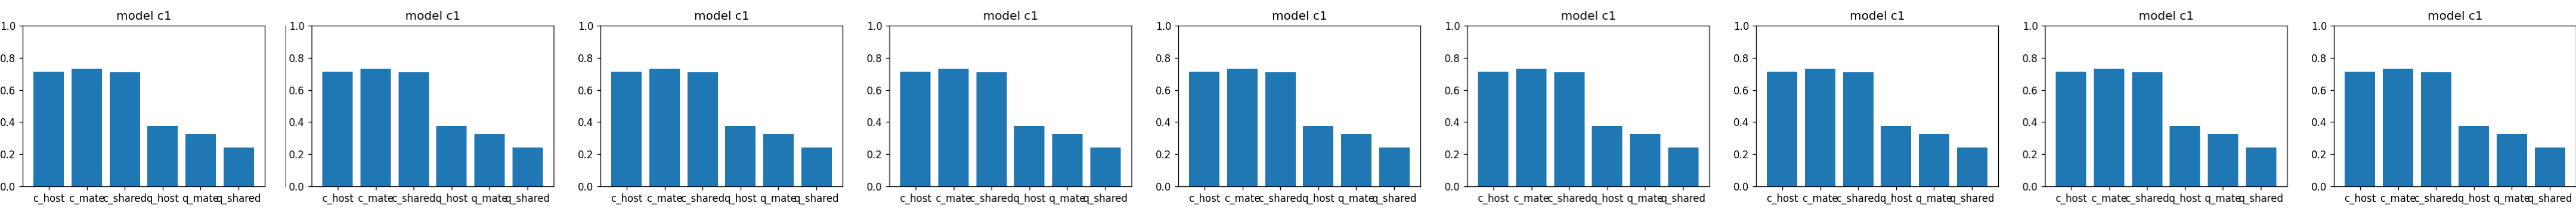

In [56]:
import cv2
import numpy as np
from PIL import Image

def parallax_views(img_path, n_views=9, max_shift=20):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    views=[]
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)

    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# Show multi-view “holo strip” for a sample
parallax_views(img_paths[0], n_views=9, max_shift=18)


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        # Returns shared-space embeddings (all normalized)
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh


In [58]:
bundle = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

torch.save(
    {
        "state_dict": bundle.state_dict(),
        "dims": {
            "E_t_aug": E_t_aug.shape[1],
            "E_i": E_i.shape[1],
            "E_a": E_a.shape[1],
            "E_v": E_v.shape[1],
            "H_T": H.shape[1],
            "H_C": H.shape[2],
        },
    },
    "holosyn_heads.pt"
)
print("Saved holosyn_heads.pt")

Saved holosyn_heads.pt


In [59]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)


WARNING    /usr/local/lib/python3.12/dist-packages/torch/__init__.py:1551: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return _C._get_float32_matmul_precision()
 [py.warnings]
  return _C._get_float32_matmul_precision()

Autotune Choices Stats:
{"num_choices": 2, "num_triton_choices": 0, "best_kernel": "addmm", "best_time": 0.28126349934609607}
AUTOTUNE addmm(49x512, 49x528, 528x512)
strides: [0, 1], [528, 1], [1, 528]
dtypes: torch.float32, torch.float32, torch.float32
  addmm 0.2813 ms 100.0% 
  bia

Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [60]:
compiled_bundle = torch.compile(bundle, mode="max-autotune")  # or mode="reduce-overhead"
compiled_bundle = compiled_bundle.eval()

# sanity forward
with torch.no_grad():
    zt, zi, za, zv, zh = compiled_bundle(E_t_aug, E_i, E_a, E_v, H)
print("Compiled forward OK:", zt.shape, zh.shape)

Compiled forward OK: torch.Size([49, 256]) torch.Size([49, 256])


In [61]:
compiled_bundle = torch.compile(bundle, mode="reduce-overhead")


In [62]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [63]:
example_inputs = (E_t_aug[:1], E_i[:1], E_a[:1], E_v[:1], H[:1])
ts = torch.jit.trace(bundle, example_inputs)
ts.save("holosyn_heads.torchscript.pt")
print("Saved holosyn_heads.torchscript.pt")


Saved holosyn_heads.torchscript.pt


In [64]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HoloSynHeads(nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc

    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh

heads = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device).eval()

# optional compile (heads only; stable)
heads = torch.compile(heads, mode="reduce-overhead")


In [65]:
import numpy as np
import torch
import torch.nn.functional as F
import soundfile as sf

class HoloSynInfer:
    def __init__(
        self,
        heads,
        embed_text_fn,
        embed_image_fn,
        embed_audio_fn,
        embed_video_fn,
        torch_device,
        # optional: synaptic + quantum augmenters (can be None)
        synaptic_fn=None,   # brian2_rate_features
        quantum_fn=None,    # quantum_features
        syn_sim_ms=25.0,
        q_n_qubits=8,
        q_reps=2,
        # synthetic haptics generator (callable)
        synth_haptics_fn=None
    ):
        self.heads = heads.eval()
        self.embed_text = embed_text_fn
        self.embed_image = embed_image_fn
        self.embed_audio = embed_audio_fn
        self.embed_video = embed_video_fn
        self.torch_device = torch_device

        self.synaptic_fn = synaptic_fn
        self.quantum_fn = quantum_fn
        self.syn_sim_ms = syn_sim_ms
        self.q_n_qubits = q_n_qubits
        self.q_reps = q_reps

        self.synth_haptics_fn = synth_haptics_fn

    def _augment_text(self, E_t: torch.Tensor) -> torch.Tensor:
        """
        E_t: (1, D) torch tensor
        returns E_t_aug: (1, D + syn + q) torch tensor
        If synaptic_fn/quantum_fn are None -> returns E_t unchanged.
        """
        if (self.synaptic_fn is None) and (self.quantum_fn is None):
            return E_t

        E_np = E_t.detach().cpu().numpy().astype(np.float32)
        parts = [E_np]

        if self.synaptic_fn is not None:
            # use first 128 dims for speed (adjust if you want)
            S = self.synaptic_fn(E_np[:, :128], sim_ms=self.syn_sim_ms)
            parts.append(S)

        if self.quantum_fn is not None:
            Q = self.quantum_fn(E_np[:, :8], n_qubits=self.q_n_qubits, reps=self.q_reps)
            parts.append(Q)

        E_aug = np.concatenate(parts, axis=1).astype(np.float32)
        E_aug = torch.tensor(E_aug, device=self.torch_device)
        return F.normalize(E_aug, dim=-1)

    def _haptics_to_tensor(self, haptics_np: np.ndarray) -> torch.Tensor:
        """
        haptics_np: (T, C) float32
        returns: (1, T, C) torch tensor
        """
        if haptics_np.ndim != 2:
            raise ValueError("haptics_np must be (T, C)")
        return torch.tensor(haptics_np[None, ...], dtype=torch.float32, device=self.torch_device)

    @torch.no_grad()
    def infer(
        self,
        text: str | None = None,
        image_path: str | None = None,
        audio_path: str | None = None,
        video_path: str | None = None,
        haptics_np: np.ndarray | None = None,
        force_synth_haptics: bool = False,
        synth_T: int = 200
    ):
        """
        Returns dict with:
          - zt, zi, za, zv, zh (each (1,256) depending on your heads)
          - plus raw modality embeddings E_* (useful for debugging)
        """
        # --- Text ---
        if text is None:
            text = ""
        E_t = self.embed_text([text])                  # (1, Dt)
        E_t = E_t.to(self.torch_device)
        E_t_aug = self._augment_text(E_t)             # (1, Dt_aug)

        # --- Image ---
        if image_path is None:
            # dummy zero vector if missing (keeps pipeline stable)
            E_i = torch.zeros((1, self.heads.p_i.net[0].in_features), device=self.torch_device)
        else:
            E_i = self.embed_image([image_path])      # (1, Di)
            E_i = E_i.to(self.torch_device)

        # --- Audio ---
        if audio_path is None:
            E_a = torch.zeros((1, self.heads.p_a.net[0].in_features), device=self.torch_device)
        else:
            E_a = self.embed_audio([audio_path])      # (1, Da)
            E_a = E_a.to(self.torch_device)

        # --- Video ---
        if video_path is None:
            E_v = torch.zeros((1, self.heads.p_v.net[0].in_features), device=self.torch_device)
        else:
            E_v = self.embed_video([video_path])      # (1, Dv)
            E_v = E_v.to(self.torch_device)

        # --- Haptics (real or synthetic) ---
        if (haptics_np is None) or force_synth_haptics:
            if self.synth_haptics_fn is None:
                # default: zeros if no generator provided
                H = torch.zeros((1, synth_T, 3), device=self.torch_device)
            else:
                # if audio exists, drive haptics from audio energy; else from text only
                H_np = self.synth_haptics_fn(audio_path=audio_path, text=text, T=synth_T)
                H = self._haptics_to_tensor(H_np)
        else:
            H = self._haptics_to_tensor(haptics_np)

        # --- Heads (shared space) ---
        zt, zi, za, zv, zh = self.heads(E_t_aug, E_i, E_a, E_v, H)

        return {
            "zt": zt, "zi": zi, "za": za, "zv": zv, "zh": zh,
            "E_t": E_t, "E_t_aug": E_t_aug, "E_i": E_i, "E_a": E_a, "E_v": E_v, "H": H
        }


In [66]:
import numpy as np
import soundfile as sf

def synth_haptics(audio_path: str | None, text: str, T: int = 200) -> np.ndarray:
    # channels: vib, pulse, force in [0,1]
    if audio_path is not None:
        audio, sr = sf.read(audio_path, dtype="float32", always_2d=True)
        wav = audio.mean(axis=1)  # (n,)
        hop = max(1, len(wav) // T)
        env = np.array([np.mean(np.abs(wav[i*hop:(i+1)*hop])) if (i*hop) < len(wav) else 0.0 for i in range(T)],
                       dtype=np.float32)
        env = (env - env.min()) / (env.max() - env.min() + 1e-8)
    else:
        # deterministic pseudo-envelope from text
        seed = (hash(text) % 10_000_000)
        rng = np.random.default_rng(seed)
        env = rng.random(T, dtype=np.float32)

    # simple “sentiment proxy”: more positive if more exclamation marks / happy tokens
    pos_hint = float(text.count("!") + text.lower().count("good") + text.lower().count("love"))
    sent = 1.0 / (1.0 + np.exp(-(pos_hint - 1.0)))  # squashed to (0,1)

    vib   = np.clip(0.15 + 0.85*(0.65*env + 0.35*sent), 0, 1)
    pulse = np.clip((1.0 - sent) * (0.25 + 0.75*env), 0, 1)
    force = np.clip(0.10 + 0.90*(0.75*env + 0.25*sent), 0, 1)

    return np.stack([vib, pulse, force], axis=1).astype(np.float32)


In [67]:
infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),   # your whisper embedding fn
    embed_video_fn=lambda ps: embed_video(ps),   # your video embedding fn
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # or None for faster inference
    quantum_fn=quantum_features,        # or None for faster inference
    synth_haptics_fn=synth_haptics
)

out = infer.infer(
    text="a calm drifting mood",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,              # None -> synthetic
    force_synth_haptics=True
)

out["zt"].shape, out["zh"].shape


cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 15, in forward
    zt = self.p_t(E_t_aug)
  File "/tmp/ipython-input-4065231866.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 16, in forward
    zi = self.p_i(E_i)
  File "/tmp/ipython-input-4065231866.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 17, in forward
    za = self.p_a(E_a)
  File "/tmp/ipython-input-4065231866.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-501203991.py", line 18, in forward
    zv = self.p_v(E_v)
  File "/tmp/ipython-input-4065231866.py", line 13, in forward
    return F.normalize(self.net(x), dim=-1)

cuda

(torch.Size([1, 256]), torch.Size([1, 256]))

In [68]:
@torch.no_grad()
def cosine_sim(a, b):
    a = F.normalize(a, dim=-1); b = F.normalize(b, dim=-1)
    return (a @ b.T)

# similarity between text and video embedding in shared space
sim_tv = cosine_sim(out["zt"], out["zv"]).item()
sim_ti = cosine_sim(out["zt"], out["zi"]).item()
sim_ta = cosine_sim(out["zt"], out["za"]).item()
sim_th = cosine_sim(out["zt"], out["zh"]).item()

(sim_tv, sim_ti, sim_ta, sim_th)


(-0.21945780515670776,
 -0.24198921024799347,
 -0.04469329118728638,
 0.43111616373062134)

In [69]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [70]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ZFuse(nn.Module):
    """
    Fuses modality embeddings into a single latent Z by weighted average.
    You can learn these weights later; for now, keep them simple.
    """
    def __init__(self, d=256):
        super().__init__()
        self.logits = nn.Parameter(torch.zeros(5))  # t,i,a,v,h weights (learnable)

    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs = []
        ws = []
        weights = torch.softmax(self.logits, dim=0)  # (5,)
        # order: t,i,a,v,h
        if zt is not None: zs.append(zt); ws.append(weights[0])
        if zi is not None: zs.append(zi); ws.append(weights[1])
        if za is not None: zs.append(za); ws.append(weights[2])
        if zv is not None: zs.append(zv); ws.append(weights[3])
        if zh is not None: zs.append(zh); ws.append(weights[4])

        if len(zs) == 0:
            raise ValueError("No modalities provided to fuse.")

        Z = 0.0
        wsum = 0.0
        for z, w in zip(zs, ws):
            Z = Z + w * z
            wsum = wsum + w
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(nn.Module):
    """
    Decode a shared latent Z -> haptic command sequence (T,3).
    Output channels: [vibration, pulse, force] in [0,1].
    """
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.out = nn.Linear(hidden, out_ch)

    def forward(self, Z, T=200):
        # Z: (B, z_dim)
        h = self.fc(Z)              # (B, hidden)
        # replicate over time
        hT = h.unsqueeze(1).repeat(1, T, 1)  # (B,T,hidden)
        y = torch.sigmoid(self.out(hT))      # (B,T,3)
        return y


In [71]:
fuse = ZFuse(d=256).to(torch_device).eval()
hdec = HapticsDecoder(z_dim=256).to(torch_device).eval()

# optional compile these too:
fuse = torch.compile(fuse, mode="reduce-overhead")
hdec = torch.compile(hdec, mode="reduce-overhead")

infer = HoloSynInfer(
    heads=heads,
    embed_text_fn=embed_text,
    embed_image_fn=embed_images,
    embed_audio_fn=lambda ps: embed_audio(ps),
    embed_video_fn=lambda ps: embed_video(ps),
    torch_device=torch_device,
    synaptic_fn=brian2_rate_features,   # set None for faster inference
    quantum_fn=quantum_features,        # set None for faster inference
    synth_haptics_fn=synth_haptics
)

In [72]:
out = infer.infer(
    text="tense mood, accelerating energy",
    image_path=img_paths[0],
    audio_path=aud_paths[0],
    video_path=vid_paths[0],
    haptics_np=None,
    force_synth_haptics=True,
    synth_T=200
)

# Perform fusion and decoding here
Z_fused = fuse(zt=out["zt"], zi=out["zi"], za=out["za"], zv=out["zv"], zh=out["zh"])
H_out = hdec(Z_fused, T=200)

out["Z_fused"] = Z_fused
out["H_out"] = H_out

print("Z_fused:", out["Z_fused"].shape)
print("H_out:", out["H_out"].shape)  # (1,200,3)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 17, in forward
    weights = torch.softmax(self.logits, dim=0)  # (5,)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 33, in forward
    Z = Z / (wsum + 1e-8)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 34, in forward
    return F.normalize(Z, dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 34, in forward
    return F.normalize(Z, dim=-1)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 53, in forward
    h = self.fc(Z)              # (B, hidden)

cudagraph partition due to non gpu ops. Found from : 
   File "/tmp/ipython-input-1620960895.py", line 53, in forward
    h = self.fc(Z)              # (B, hidden)

cudagraph partition due to non gpu ops. Foun

Z_fused: torch.Size([1, 256])
H_out: torch.Size([1, 200, 3])


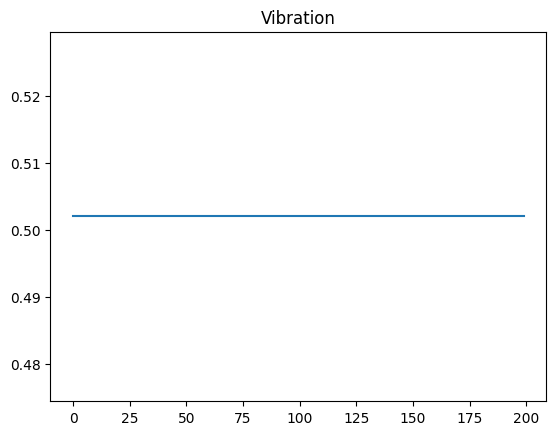

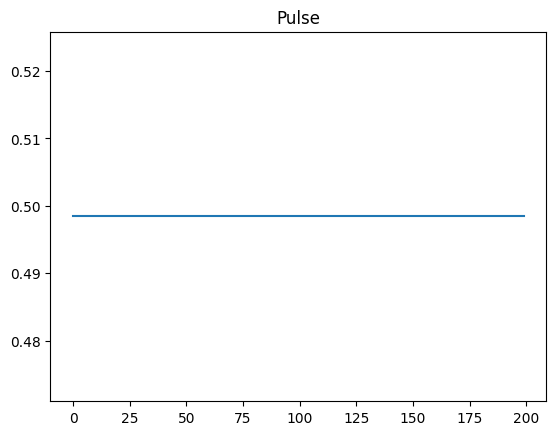

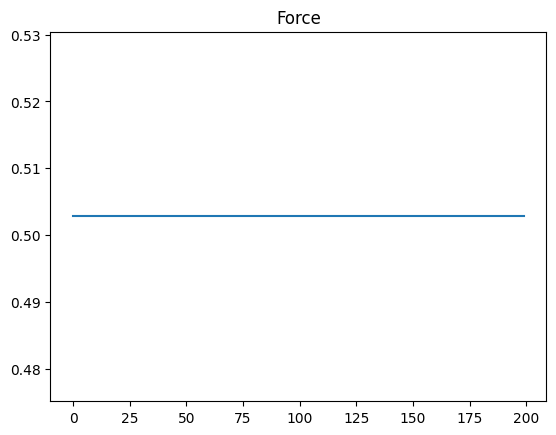

In [73]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()


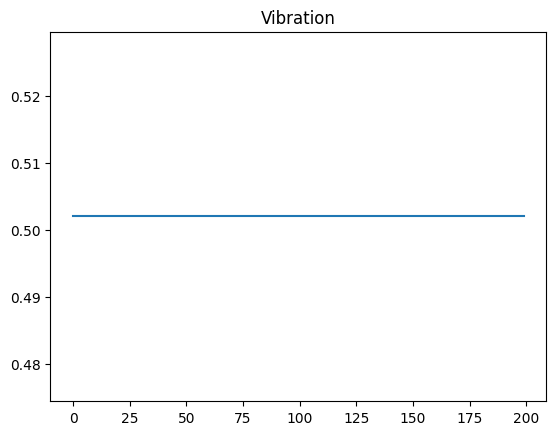

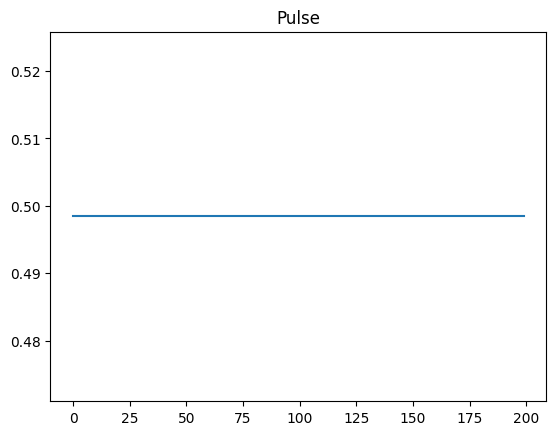

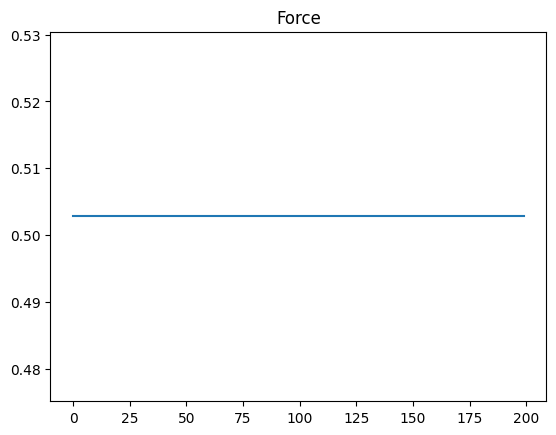

In [74]:
import matplotlib.pyplot as plt
H = out["H_out"].squeeze(0).detach().cpu().numpy()  # (T,3)

plt.figure()
plt.plot(H[:,0]); plt.title("Vibration")
plt.figure()
plt.plot(H[:,1]); plt.title("Pulse")
plt.figure()
plt.plot(H[:,2]); plt.title("Force")
plt.show()

In [75]:
!zip -r /content/filec.zip /content

updating: content/ (stored 0%)
updating: content/.config/ (stored 0%)
updating: content/.config/logs/ (stored 0%)
updating: content/.config/logs/2026.01.16/ (stored 0%)
updating: content/.config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
updating: content/.config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
updating: content/.config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)
updating: content/.config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
updating: content/.config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
updating: content/.config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
updating: content/.config/.last_opt_in_prompt.yaml (stored 0%)
updating: content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
updating: content/.config/configurations/ (stored 0%)
updating: content/.config/configurations/config_default (deflated 15%)
updating: content/.config/.last_update_check.json (deflated 22%)
updating: co

In [76]:
from google.colab import files
files.download("/content/filec.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# HoloSyn Visual Interface (Inputs → Shared Latent → Outputs)

This UI lets you:
- Provide **text / image / audio / video** (any subset)
- Generate **synthetic haptics** (or upload your own later)
- Get **shared-space embeddings**, similarity scores, and **generated haptic waveform**
- Render a **"hologram-like" parallax strip** from an image

> Tip: If you haven't run the training cells yet, run them first so `heads`, `infer`, etc. exist.  
> The UI will also try to load `holosyn_heads.pt` if present.


In [77]:
!pip -q install gradio matplotlib


In [100]:
# --- Encoder Setup (defines embed_text, embed_images, embed_audio, embed_video) ---
import torch
import torch.nn.functional as F

torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch_device:", torch_device)

# 1) TEXT (transformers)
from transformers import AutoTokenizer, AutoModel

TEXT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
txt_tok = AutoTokenizer.from_pretrained(TEXT_MODEL)
txt_model = AutoModel.from_pretrained(TEXT_MODEL).to(torch_device).eval()

@torch.no_grad()
def embed_text(texts):
    batch = txt_tok(texts, padding=True, truncation=True, return_tensors="pt").to(torch_device)
    out = txt_model(**batch).last_hidden_state
    mask = batch["attention_mask"].unsqueeze(-1)
    pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
    return F.normalize(pooled, dim=-1)

# 2) IMAGE (open_clip)
import open_clip
from PIL import Image

clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k"
)
clip_model = clip_model.to(torch_device).eval()

@torch.no_grad()
def embed_images(paths):
    ims = [clip_preprocess(Image.open(p).convert("RGB")) for p in paths]
    x = torch.stack(ims).to(torch_device)
    z = clip_model.encode_image(x)
    return F.normalize(z, dim=-1)

# 3) AUDIO (whisper)
import whisper
whisper_device = "cuda" if torch.cuda.is_available() else "cpu"
wh_model = whisper.load_model("base", device=whisper_device)

@torch.no_grad()
def embed_audio(paths):
    embs = []
    for p in paths:
        audio = whisper.load_audio(p)
        audio = whisper.pad_or_trim(audio)
        mel = whisper.log_mel_spectrogram(audio).to(whisper_device)
        enc = wh_model.encoder(mel.unsqueeze(0))  # (1,frames,dim)
        emb = enc.mean(dim=1).squeeze(0)
        embs.append(emb.to(torch_device))         # keep outputs on torch_device
    embs = torch.stack(embs)
    return F.normalize(embs, dim=-1)

# 4) VIDEO (frame sampling + CLIP pooling)
import decord
import torchvision.transforms as T
decord.bridge.set_bridge("torch")

@torch.no_grad()
def embed_video(paths, num_frames=8):
    all_embs = []
    for p in paths:
        vr = decord.VideoReader(p)
        n = len(vr)
        idx = torch.linspace(0, max(n-1,0), steps=min(num_frames, n)).long()
        frames = vr.get_batch(idx)
        # Explicitly convert to torch.Tensor if decord.bridge.set_bridge("torch") isn't working
        if not isinstance(frames, torch.Tensor):
            frames = torch.from_numpy(frames.asnumpy())

        frames = frames.to(torch_device)
        frames = frames.permute(0,3,1,2)  # (F,C,H,W)
        frames_pil = [T.ToPILImage()(f.cpu()) for f in frames]
        frames_t = torch.stack([clip_preprocess(im) for im in frames_pil]).to(torch_device)
        zf = clip_model.encode_image(frames_t)
        zv = zf.mean(dim=0)
        all_embs.append(zv)
    all_embs = torch.stack(all_embs)
    return F.normalize(all_embs, dim=-1)

print("✅ Embedding fns ready:", [embed_text, embed_images, embed_audio, embed_video])

torch_device: cpu
✅ Embedding fns ready: [<function embed_text at 0x7d3f48e30cc0>, <function embed_images at 0x7d3f52c1cfe0>, <function embed_audio at 0x7d3f52bb4720>, <function embed_video at 0x7d3f52bb4680>]


In [ ]:
import os, io, json, math, tempfile
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import gradio as gr

# ---------- Safety: avoid Brian2 clobbering torch device ----------
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Minimal modules for loading if needed ----------
class Projector(torch.nn.Module):
    def __init__(self, in_dim, out_dim=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(in_dim, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, out_dim),
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)

class HapticsEncoder(torch.nn.Module):
    def __init__(self, in_ch=3, out_dim=256):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Conv1d(in_ch, 32, kernel_size=7, padding=3),
            torch.nn.ReLU(),
            torch.nn.Conv1d(32, 64, kernel_size=7, padding=3),
            torch.nn.ReLU(),
            torch.nn.AdaptiveAvgPool1d(1),
        )
        self.proj = torch.nn.Linear(64, out_dim)
    def forward(self, x):  # (B,T,C)
        x = x.transpose(1,2)        # (B,C,T)
        h = self.net(x).squeeze(-1) # (B,64)
        z = self.proj(h)
        return F.normalize(z, dim=-1)

class HoloSynHeads(torch.nn.Module):
    def __init__(self, p_t, p_i, p_a, p_v, h_enc):
        super().__init__()
        self.p_t = p_t
        self.p_i = p_i
        self.p_a = p_a
        self.p_v = p_v
        self.h_enc = h_enc
    def forward(self, E_t_aug, E_i, E_a, E_v, H):
        zt = self.p_t(E_t_aug)
        zi = self.p_i(E_i)
        za = self.p_a(E_a)
        zv = self.p_v(E_v)
        zh = self.h_enc(H)
        return zt, zi, za, zv, zh

class ZFuse(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.logits = torch.nn.Parameter(torch.zeros(5))  # t,i,a,v,h
    def forward(self, zt=None, zi=None, za=None, zv=None, zh=None):
        zs, ws = [], []
        w = torch.softmax(self.logits, dim=0)
        if zt is not None: zs.append(zt); ws.append(w[0])
        if zi is not None: zs.append(zi); ws.append(w[1])
        if za is not None: zs.append(za); ws.append(w[2])
        if zv is not None: zs.append(zv); ws.append(w[3])
        if zh is not None: zs.append(zh); ws.append(w[4])
        if not zs:
            raise ValueError("No modalities provided.")
        Z = 0.0
        wsum = 0.0
        for zi_, wi_ in zip(zs, ws):
            Z = Z + wi_ * zi_
            wsum = wsum + wi_
        Z = Z / (wsum + 1e-8)
        return F.normalize(Z, dim=-1)

class HapticsDecoder(torch.nn.Module):
    def __init__(self, z_dim=256, hidden=256, out_ch=3):
        super().__init__()
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(z_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
        )
        self.out = torch.nn.Linear(hidden, out_ch)
    def forward(self, Z, T=200):
        h = self.fc(Z)
        hT = h.unsqueeze(1).repeat(1, T, 1)
        y = torch.sigmoid(self.out(hT))
        return y

# ---------- Utility: render "hologram-like" parallax strip ----------
import cv2

def parallax_strip(img_path, n_views=9, max_shift=18):
    if img_path is None or not os.path.exists(img_path):
        return None
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    h,w,_ = img.shape
    shifts = np.linspace(-max_shift, max_shift, n_views).astype(np.float32)
    views=[]
    for s in shifts:
        M = np.float32([[1,0,s],[0,1,0]])
        shifted = cv2.warpAffine(img, M, (w,h), borderMode=cv2.BORDER_REFLECT)
        views.append(shifted)
    grid = np.concatenate(views, axis=1)
    return Image.fromarray(grid)

# ---------- Synthetic haptics ----------
import soundfile as sf

def synth_haptics(audio_path: str | None, text: str, T: int = 200) -> np.ndarray:
    if audio_path is not None and os.path.exists(audio_path):
        audio, sr = sf.read(audio_path, dtype="float32", always_2d=True)
        wav = audio.mean(axis=1)
        hop = max(1, len(wav)//T)
        env = np.array([np.mean(np.abs(wav[i*hop:(i+1)*hop])) if i*hop < len(wav) else 0.0 for i in range(T)],
                       dtype=np.float32)
        env = (env - env.min()) / (env.max() - env.min() + 1e-8)
    else:
        rng = np.random.default_rng(hash(text) % 10_000_000)
        env = rng.random(T, dtype=np.float32)

    pos_hint = float(text.count("!") + text.lower().count("good") + text.lower().count("love"))
    sent = 1.0 / (1.0 + np.exp(-(pos_hint - 1.0)))

    vib   = np.clip(0.15 + 0.85*(0.65*env + 0.35*sent), 0, 1)
    pulse = np.clip((1.0 - sent) * (0.25 + 0.75*env), 0, 1)
    force = np.clip(0.10 + 0.90*(0.75*env + 0.25*sent), 0, 1)
    return np.stack([vib, pulse, force], axis=1).astype(np.float32)

def haptics_plot_image(H_np: np.ndarray):
    # H_np: (T,3)
    fig = plt.figure(figsize=(10,3))
    ax = fig.add_subplot(111)
    ax.plot(H_np[:,0], label="vibration")
    ax.plot(H_np[:,1], label="pulse")
    ax.plot(H_np[:,2], label="force")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="upper right", ncol=3, fontsize=8)
    ax.set_title("Generated haptic command waveform")
    ax.set_xlabel("time step")
    buf = io.BytesIO()
    fig.tight_layout()
    fig.savefig(buf, format="png", dpi=140)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf)

# ---------- Build / load inference objects ----------
def build_runtime():
    global heads, fuse, hdec
    # If user already trained in this notebook, prefer existing globals
    if "heads" in globals() and isinstance(globals()["heads"], torch.nn.Module):
        _heads = globals()["heads"].to(torch_device).eval()
    else:
        ckpt = "holosyn_heads.pt"
        if not os.path.exists(ckpt):
            raise FileNotFoundError(
                "Couldn't find trained heads. Run the training cells first, or place holosyn_heads.pt in the notebook folder."
            )
        blob = torch.load(ckpt, map_location="cpu")
        sd = blob["state_dict"]
        dims = blob["dims"]
        # Create modules with correct input dims
        p_t = Projector(dims["E_t_aug"]).to(torch_device)
        p_i = Projector(dims["E_i"]).to(torch_device)
        p_a = Projector(dims["E_a"]).to(torch_device)
        p_v = Projector(dims["E_v"]).to(torch_device)
        h_enc = HapticsEncoder(in_ch=dims.get("H_C", 3), out_dim=256).to(torch_device)
        _heads = HoloSynHeads(p_t, p_i, p_a, p_v, h_enc).to(torch_device)
        _heads.load_state_dict(sd, strict=True)
        _heads.eval()

    _fuse = globals().get("fuse", ZFuse().to(torch_device).eval())
    _hdec = globals().get("hdec", HapticsDecoder().to(torch_device).eval())
    return _heads, _fuse, _hdec

# ---------- Core inference wrapper (expects your embed_* fns exist) ----------
def ensure_embed_fns():
    missing = [n for n in ["embed_text","embed_images","embed_audio","embed_video"] if n not in globals()]
    if missing:
        raise NameError(
            f"Missing embedding functions: {missing}. "
            f"Run the 'Encoder Setup' cell (the one that defines embed_text/embed_images/embed_audio/embed_video) first."
        )
    return embed_text, embed_images, embed_audio, embed_video
def to_tensor_haptics(H_np):
    return torch.tensor(H_np[None,...], dtype=torch.float32, device=torch_device)

@torch.no_grad()
def run_infer(text, image_file, audio_file, video_file, use_synaptic, use_quantum, T):
    # Resolve paths from Gradio (may pass dict or str depending on version)
    def get_path(f):
        if f is None: return None
        if isinstance(f, str): return f
        if isinstance(f, dict) and "name" in f: return f["name"]
        if hasattr(f, "name"): return f.name
        return None

    img_path = get_path(image_file)
    aud_path = get_path(audio_file)
    vid_path = get_path(video_file)

    embed_text, embed_images, embed_audio, embed_video = ensure_embed_fns()
    _heads, _fuse, _hdec = build_runtime()

    # Embeddings
    E_t = embed_text([text]).to(torch_device)

    # Initialize E_t_aug with E_t
    E_t_aug = E_t

    # Apply augmentations if selected
    if use_synaptic:
        if "brian2_rate_features" not in globals():
            raise NameError("brian2_rate_features not found. Run the Brian2 cell first or disable synaptic augmentation.")
        E_np = E_t_aug.detach().cpu().numpy().astype("float32") # Use E_t_aug for sequential augmentation
        S = globals()["brian2_rate_features"](E_np[:, :128], sim_ms=25.0)
        E_t_aug = torch.tensor(np.concatenate([E_np, S], axis=1), device=torch_device, dtype=torch.float32)
        E_t_aug = F.normalize(E_t_aug, dim=-1)

    if use_quantum:
        if "quantum_features" not in globals():
            raise NameError("quantum_features not found. Run the Cirq/qsim cell first or disable quantum augmentation.")
        E_np = E_t_aug.detach().cpu().numpy().astype("float32") # Use E_t_aug for sequential augmentation
        Q = globals()["quantum_features"](E_np[:, :8], n_qubits=8, reps=2)
        E_t_aug = torch.tensor(np.concatenate([E_np, Q], axis=1), device=torch_device, dtype=torch.float32)
        E_t_aug = F.normalize(E_t_aug, dim=-1)

    # Pad E_t_aug to match the expected input dimension of p_t if necessary
    expected_p_t_dim = _heads.p_t.net[0].in_features
    if E_t_aug.shape[1] < expected_p_t_dim:
        padding_size = expected_p_t_dim - E_t_aug.shape[1]
        E_t_aug = F.pad(E_t_aug, (0, padding_size), 'constant', 0)
    elif E_t_aug.shape[1] > expected_p_t_dim:
        # This case should ideally not happen if augmentations are correctly applied in order
        # but adding a safeguard or warning might be useful if logic changes.
        print(f"Warning: E_t_aug dimension ({E_t_aug.shape[1]}) is larger than expected ({expected_p_t_dim}). Truncating.")
        E_t_aug = E_t_aug[:, :expected_p_t_dim]

    # Other modalities (optional)
    E_i = embed_images([img_path]).to(torch_device) if img_path else torch.zeros((1, _heads.p_i.net[0].in_features), device=torch_device)
    E_a = embed_audio([aud_path]).to(torch_device) if aud_path else torch.zeros((1, _heads.p_a.net[0].in_features), device=torch_device)
    E_v = embed_video([vid_path]).to(torch_device) if vid_path else torch.zeros((1, _heads.p_v.net[0].in_features), device=torch_device)

    # Haptics in (synthetic for now)
    H_np = synth_haptics(aud_path, text, T=T)
    H = to_tensor_haptics(H_np)

    # Heads
    zt_raw, zi_raw, za_raw, zv_raw, zh_raw = _heads(E_t_aug, E_i, E_a, E_v, H)

    # Clone outputs to prevent CUDA graph overwrites
    zt = zt_raw.clone()
    zi = zi_raw.clone()
    za = za_raw.clone()
    zv = zv_raw.clone()
    zh = zh_raw.clone()

    # Fuse (only include provided modalities)
    zi_use = None if not img_path else zi
    za_use = None if not aud_path else za
    zv_use = None if not vid_path else zv
    Z = _fuse(zt=zt, zi=zi_use, za=za_use, zv=zv_use, zh=zh)

    # Decode haptics out
    H_out = _hdec(Z, T=T).squeeze(0).detach().cpu().numpy()

    # Similarities vs text
    def cos(a,b):
        return float((F.normalize(a,dim=-1) @ F.normalize(b,dim=-1).T).item())

    sims = {
        "text\u2194image": cos(zt, zi),
        "text\u2194audio": cos(zt, za),
        "text\u2194video": cos(zt, zv),
        "text\u2194haptics": cos(zt, zh),
        "fused\u2194text": cos(Z, zt),
    }
    sims_md = "\n".join([f"- **{k}**: `{v:.4f}`" for k,v in sims.items()])

    # Outputs
    holo = parallax_strip(img_path) if img_path else None
    hap_plot = haptics_plot_image(H_out)

    # Provide downloadable .npy for haptics out
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix=".npy")
    np.save(tmp.name, H_out.astype(np.float32))
    tmp.close()

    return sims_md, holo, hap_plot, tmp.name

# ---------- Launch Gradio UI ----------
with gr.Blocks(title="HoloSyn Multimodal Interface") as demo:
    gr.Markdown("## HoloSyn Multimodal Interface\nProvide any subset of inputs. The model returns similarity scores, a hologram-like parallax strip (if an image is provided), and generated haptic commands.")

    with gr.Row():
        with gr.Column(scale=2):
            text_in = gr.Textbox(label="Text prompt", lines=3, value="a calm drifting mood")
            img_in  = gr.File(label="Image (png/jpg)", file_types=["image"])
            aud_in  = gr.File(label="Audio (wav/mp3)", file_types=["audio"])
            vid_in  = gr.File(label="Video (mp4)", file_types=["video"])

            with gr.Row():
                syn_in = gr.Checkbox(label="Use synaptic (Brian2) text augmentation", value=False)
                q_in   = gr.Checkbox(label="Use quantum (Cirq/qsim) text augmentation", value=False)

            T_in = gr.Slider(minimum=50, maximum=400, value=200, step=10, label="Haptics length T")

            run_btn = gr.Button("Run")

        with gr.Column(scale=3):
            sims_out = gr.Markdown(label="Similarity scores")
            holo_out = gr.Image(label="Hologram-like parallax strip (from image)")
            hap_out  = gr.Image(label="Generated haptic waveform")
            hfile_out = gr.File(label="Download generated haptics (.npy)")

    run_btn.click(
        fn=run_infer,
        inputs=[text_in, img_in, aud_in, vid_in, syn_in, q_in, T_in],
        outputs=[sims_out, holo_out, hap_out, hfile_out],
    )

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://f348f5c99c567136a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [97]:
student_loaded = StudentDistilledModel(dt, di, da, dv, z=256).to(torch_device)
load_student(student_loaded, "student_distilled.pt")
student_loaded.eval()

print("Student model loaded successfully:", student_loaded)

Student model loaded successfully: StudentDistilledModel(
  (text): Sequential(
    (0): Linear(in_features=384, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (img): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (aud): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (vid): Sequential(
    (0): Linear(in_features=512, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
  )
  (fuse_gate): Sequential(
    (0): Linear(in_features=1028, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [80]:
# Distilled student model (multimodal -> shared Z)
import os, json, zipfile, shutil, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# IMPORTANT: use torch_device for PyTorch to avoid Brian2 clobbering "device"
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch_device:", torch_device)

class StudentDistilledModel(nn.Module):
    """Small student: modality embeddings -> Z(256). Handles missing modalities via mask.
    mask order: [text, image, audio, video]
    """
    def __init__(self, dt, di, da, dv, z=256, hidden=512):
        super().__init__()
        self.z = z
        self.text = nn.Sequential(nn.Linear(dt, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.img  = nn.Sequential(nn.Linear(di, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.aud  = nn.Sequential(nn.Linear(da, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.vid  = nn.Sequential(nn.Linear(dv, hidden), nn.ReLU(), nn.Linear(hidden, z))
        self.fuse_gate = nn.Sequential(
            nn.Linear(z*4 + 4, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

    def forward(self, E_t, E_i, E_a, E_v, mask):
        zt = self.text(E_t)
        zi = self.img(E_i)
        za = self.aud(E_a)
        zv = self.vid(E_v)

        z_stack = torch.cat([zt, zi, za, zv], dim=-1)
        g = self.fuse_gate(torch.cat([z_stack, mask], dim=-1))
        g = g.masked_fill(mask == 0, -1e9)
        w = torch.softmax(g, dim=-1)

        Z = (w[:,0:1]*zt + w[:,1:2]*zi + w[:,2:3]*za + w[:,3:4]*zv)
        return F.normalize(Z, dim=-1), (F.normalize(zt, dim=-1), F.normalize(zi, dim=-1),
                                       F.normalize(za, dim=-1), F.normalize(zv, dim=-1)), w

def save_student(student, path="student_distilled.pt"):
    torch.save({"state_dict": student.state_dict()}, path)
    print("Saved:", path)

def load_student(student, path="student_distilled.pt"):
    ck = torch.load(path, map_location=torch_device)
    student.load_state_dict(ck["state_dict"], strict=True)
    return student

torch_device: cpu


In [88]:
# Train distilled student model
# Distill the student from your trained teacher heads (_heads) using synthdata.zip (49 samples).
# Requires embed_text/embed_images/embed_audio/embed_video already defined.

import os, json, zipfile, shutil
import torch
import torch.nn.functional as F

ZIP_PATH = "./data/synthdata.zip"
OUT_DIR = "./data_distill"

if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(OUT_DIR)

ROOT = os.path.join(OUT_DIR, "synthdata", "synth")
manifest_path = os.path.join(ROOT, "manifest.jsonl")

def fix_path(p):
    if isinstance(p, str) and p.startswith("/content/synth/"):
        rel = p.replace("/content/synth/", "")
        return os.path.join(ROOT, rel)
    return p

def pick(j, *keys):
    for k in keys:
        if k in j and j[k]:
            return j[k]
    return None

items=[]
with open(manifest_path, "r", encoding="utf-8") as f:
    for line in f:
        items.append(json.loads(line))

texts, img_paths, aud_paths, vid_paths = [], [], [], []
for j in items:
    texts.append(j.get("text",""))
    img_paths.append(fix_path(pick(j, "image_path", "img_path")))
    aud_paths.append(fix_path(pick(j, "audio_path", "aud_path")))
    vid_paths.append(fix_path(pick(j, "video_path", "vid_path")))

missing = [n for n in ["embed_text","embed_images","embed_audio","embed_video"] if n not in globals()]
if missing:
    raise NameError(f"Missing embedding functions: {missing}. Run encoder setup cell first.")

E_t = embed_text(texts).to(torch_device)
E_i = embed_images(img_paths).to(torch_device)
E_a = embed_audio(aud_paths).to(torch_device)
E_v = embed_video(vid_paths).to(torch_device)

dt, di, da, dv = E_t.shape[1], E_i.shape[1], E_a.shape[1], E_v.shape[1]
print("Dims:", dt, di, da, dv)

use_teacher = "_heads" in globals()
print("Teacher available:", use_teacher)

@torch.no_grad()
def teacher_Z(E_t, E_i, E_a, E_v):
    zt, zi, za, zv, zh = _heads(E_t, E_i, E_a, E_v, torch.zeros((E_t.shape[0],200,3), device=torch_device))
    return F.normalize((zt + zi + za + zv) / 4.0, dim=-1)

student = StudentDistilledModel(dt, di, da, dv, z=256).to(torch_device)

if use_teacher:
    Z_target = teacher_Z(E_t, E_i, E_a, E_v)
else:
    # When no teacher is available, use the student's own text projection as the target.
    # This ensures dimension matching (256) and a self-distillation-like objective for text.
    with torch.no_grad():
        _zt_for_target = student.text(E_t)
    Z_target = F.normalize(_zt_for_target, dim=-1)

opt = torch.optim.AdamW(student.parameters(), lr=2e-3, weight_decay=1e-4)
mask = torch.ones((E_t.shape[0], 4), device=torch_device)

def cosine_loss(a, b):
    return 1.0 - (a*b).sum(dim=-1).mean()

student.train()
for epoch in range(1, 401):
    Zs, _, w = student(E_t, E_i, E_a, E_v, mask)
    loss = cosine_loss(Zs, Z_target)
    opt.zero_grad()
    loss.backward()
    opt.step()
    if epoch % 50 == 0 or epoch == 1:
        print(f"epoch {epoch:4d} loss {loss.item():.4f} w_mean {w.mean(dim=0).detach().cpu().numpy()}")

student.eval()
save_student(student, "student_distilled.pt")

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^

Dims: 384 512 512 512
Teacher available: False
epoch    1 loss 0.3908 w_mean [0.24082367 0.25588366 0.23180127 0.27149138]
epoch   50 loss 0.0015 w_mean [0.9804903  0.00365332 0.01140682 0.00444951]
epoch  100 loss 0.0006 w_mean [9.9983579e-01 5.9346268e-05 5.2414754e-05 5.2479900e-05]
epoch  150 loss 0.0004 w_mean [9.9986744e-01 4.6272347e-05 4.3495322e-05 4.2778374e-05]
epoch  200 loss 0.0002 w_mean [9.9988079e-01 4.0239061e-05 4.0395873e-05 3.8553564e-05]
epoch  250 loss 0.0002 w_mean [9.9988931e-01 3.6514073e-05 3.8430935e-05 3.5784080e-05]
epoch  300 loss 0.0001 w_mean [9.998932e-01 3.472327e-05 3.762966e-05 3.448049e-05]
epoch  350 loss 0.0001 w_mean [9.9989527e-01 3.3700951e-05 3.7333317e-05 3.3772245e-05]
epoch  400 loss 0.0001 w_mean [9.9989653e-01 3.2973341e-05 3.7221060e-05 3.3284712e-05]
Saved: student_distilled.pt


In [87]:
# UI: audio+video+image+text -> distilled student output
# UI: audio+video+image+text -> distilled student output
import gradio as gr
import numpy as np
import tempfile, os
import matplotlib.pyplot as plt
from PIL import Image
import torch

missing = [n for n in ["embed_text","embed_images","embed_audio","embed_video"] if n not in globals()]
if missing:
    raise NameError(f"Missing embedding functions: {missing}. Run encoder setup cell first.")

def _path_from_upload(u):
    if u is None:
        return None
    if isinstance(u, str):
        return u
    if isinstance(u, dict) and "name" in u:
        return u["name"]
    return None

def ensure_student_for_dims(dt, di, da, dv):
    global student
    needs_new = ("student" not in globals())
    if not needs_new:
        needs_new = (student.text[0].in_features != dt or student.img[0].in_features != di or
                     student.aud[0].in_features != da or student.vid[0].in_features != dv)
    if needs_new:
        student = StudentDistilledModel(dt, di, da, dv, z=256).to(torch_device).eval()
        if os.path.exists("student_distilled.pt"):
            load_student(student, "student_distilled.pt")
            student.eval()
    return student

def _blank_image_path():
    blank = Image.new("RGB", (224,224), color=(0,0,0))
    tmp = tempfile.NamedTemporaryFile(suffix=".png", delete=False)
    blank.save(tmp.name)
    return tmp.name

def _plot_haptics(Z, T=200):
    z = Z.detach().cpu().numpy().reshape(-1)
    t = np.linspace(0, 1, T).astype(np.float32)
    vib = 0.5 + 0.5*np.sin(2*np.pi*(3+2*z[0])*t)
    pulse = 0.5 + 0.5*np.sin(2*np.pi*(6+3*z[1])*t)
    force = 0.5 + 0.5*np.sin(2*np.pi*(2+1*z[2])*t)
    H = np.stack([vib, pulse, force], axis=1)
    fig = plt.figure()
    plt.plot(H[:,0]); plt.title("Distilled model haptics output (placeholder): vibration")
    return fig, H

@torch.no_grad()
def run_student(text, image, audio, video):
    text = "" if text is None else text
    img_path = _path_from_upload(image)
    aud_path = _path_from_upload(audio)
    vid_path = _path_from_upload(video)

    Et = embed_text([text]).to(torch_device)

    if img_path:
        Ei = embed_images([img_path]).to(torch_device); mi = 1.0
    else:
        p = _blank_image_path()
        Ei0 = embed_images([p]).to(torch_device)
        os.unlink(p)
        Ei = torch.zeros_like(Ei0); mi = 0.0

    if aud_path:
        Ea = embed_audio([aud_path]).to(torch_device); ma = 1.0
    else:
        # placeholder zeros; if student exists we'll align dims
        Ea = torch.zeros((1, 512), device=torch_device); ma = 0.0

    if vid_path:
        Ev = embed_video([vid_path]).to(torch_device); mv = 1.0
    else:
        Ev = torch.zeros((1, Ei.shape[1]), device=torch_device); mv = 0.0

    # If audio missing and student exists, adjust Ea dim to student expectation
    if aud_path is None and ("student" in globals()):
        Ea = torch.zeros((1, student.aud[0].in_features), device=torch_device)

    # Ensure student matches dims
    student_local = ensure_student_for_dims(Et.shape[1], Ei.shape[1], Ea.shape[1], Ev.shape[1])

    # If audio missing and student was rebuilt, adjust Ea accordingly
    if aud_path is None:
        Ea = torch.zeros((1, student_local.aud[0].in_features), device=torch_device)

    mask = torch.tensor([[1.0, mi, ma, mv]], device=torch_device)
    Z, (zt, zi, za, zv), w = student_local(Et, Ei, Ea, Ev, mask)

    sims = {
        "text↔image": float((zt*zi).sum().item()) if mi else None,
        "text↔audio": float((zt*za).sum().item()) if ma else None,
        "text↔video": float((zt*zv).sum().item()) if mv else None,
    }

    fig, H = _plot_haptics(Z, T=200)
    out = {
        "Z_student_shape": list(Z.shape),
        "fusion_weights_[t,i,a,v]": w.detach().cpu().numpy().reshape(-1).tolist(),
        "similarities": sims,
    }
    return out, fig, H

with gr.Blocks() as demo:
    gr.Markdown("## Distilled Multimodal UI (Student)\nInputs: text + optional image/audio/video. Outputs are from the distilled student model.")
    text_in = gr.Textbox(label="Text", lines=3)
    with gr.Row():
        img_in = gr.File(label="Image", file_types=["image"])
        aud_in = gr.File(label="Audio", file_types=["audio"])
        vid_in = gr.File(label="Video", file_types=["video"])
    btn = gr.Button("Run Distilled Model")
    out_json = gr.JSON(label="Student output")
    out_plot = gr.Plot(label="Haptics output (placeholder)")
    out_arr = gr.Dataframe(label="Haptics array (T x 3)", interactive=False)
    btn.click(run_student, inputs=[text_in, img_in, aud_in, vid_in], outputs=[out_json, out_plot, out_arr])

demo.launch(debug=False, share=True, show_error=True, prevent_thread_lock=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7e8a66f273e27c8d60.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
